# 🎵 MoodPulse — Fine-tuning DistilBERT on GoEmotions

**Goal:** Fine-tune `distilbert-base-uncased` on Google's GoEmotions dataset to classify text (lyrics) into 6 core emotions:
- 😄 Joy
- 😢 Sadness  
- 😠 Anger
- 😨 Fear
- 💖 Love
- 😲 Surprise



## Cell 1 — Install dependencies

In [ ]:
!pip install -q transformers datasets evaluate accelerate huggingface_hub scikit-learn seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00


## Cell 2 — Login to HuggingFace Hub
Get your token at: https://huggingface.co/settings/tokens → New token → Write access

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from huggingface_hub import whoami, HfApi
#Run this cell to create the repo manually
me = whoami()
print(f"Logged in as: {me['name']}")

api = HfApi()

# Try creating the repo manually first
try:
    repo = api.create_repo(
        repo_id="moodpulse-emotion",
        repo_type="model",
        exist_ok=True  # won't fail if it already exists
    )
    print(f"Repo ready: {repo}")
except Exception as e:
    print(f"Error: {e}")

## Cell 3 — Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import evaluate
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


## Cell 4 — Load GoEmotions dataset & map to 6 core emotions

In [ ]:
# GoEmotions has 28 emotion labels — we collapse them into 6 core moods
# that make sense for music mood prediction

EMOTION_MAPPING = {
    # Joy (0)
    'admiration': 0, 'amusement': 0, 'approval': 0, 'excitement': 0,
    'gratitude': 0, 'joy': 0, 'optimism': 0, 'relief': 0, 'pride': 0,
    # Sadness (1)
    'disappointment': 1, 'disapproval': 1, 'embarrassment': 1,
    'grief': 1, 'remorse': 1, 'sadness': 1,
    # Anger (2)
    'anger': 2, 'annoyance': 2, 'disgust': 2,
    # Fear (3)
    'fear': 3, 'nervousness': 3,
    # Love (4)
    'caring': 4, 'desire': 4, 'love': 4,
    # Surprise (5)
    'confusion': 5, 'curiosity': 5, 'realization': 5, 'surprise': 5,
    # Neutral — we'll keep it as a separate label or skip
    'neutral': -1
}

LABEL_NAMES = ['joy', 'sadness', 'anger', 'fear', 'love', 'surprise']
LABEL_EMOJIS = ['😄', '😢', '😠', '😨', '💖', '😲']

print("Loading GoEmotions dataset...")
raw_dataset = load_dataset('go_emotions', 'simplified')
print(raw_dataset)
print("\nSample:", raw_dataset['train'][0])

Loading GoEmotions dataset...


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Sample: {'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


## Cell 5 — Preprocess & remap labels

In [ ]:
# GoEmotions simplified has 28 labels
go_emotions_labels = raw_dataset['train'].features['labels'].feature.names
print("GoEmotions labels:", go_emotions_labels)

def remap_labels(example):
    """Map GoEmotions 28-label multi-label to our 6-class single-label."""
    mapped = set()
    for label_id in example['labels']:
        label_name = go_emotions_labels[label_id]
        mapped_id = EMOTION_MAPPING.get(label_name, -1)
        if mapped_id != -1:
            mapped.add(mapped_id)

    # Take the first mapped emotion, skip if neutral or empty
    if len(mapped) == 0:
        return {'label': -1, 'text': example['text']}

    # Priority: love > joy > sadness > anger > fear > surprise
    priority = [4, 0, 1, 2, 3, 5]
    for p in priority:
        if p in mapped:
            return {'label': p, 'text': example['text']}

    return {'label': list(mapped)[0], 'text': example['text']}

print("\nRemapping labels...")
processed = {}
for split in ['train', 'validation', 'test']:
    mapped = raw_dataset[split].map(remap_labels, remove_columns=['id', 'labels'])
    # Filter out neutral (-1)
    mapped = mapped.filter(lambda x: x['label'] != -1)
    processed[split] = mapped
    print(f"{split}: {len(mapped)} samples after filtering")

dataset = DatasetDict(processed)
print("\nDone! Dataset ready.")

GoEmotions labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

Remapping labels...


Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Filter:   0%|          | 0/43410 [00:00<?, ? examples/s]

train: 30587 samples after filtering


Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5426 [00:00<?, ? examples/s]

validation: 3834 samples after filtering


Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5427 [00:00<?, ? examples/s]

test: 3821 samples after filtering

Done! Dataset ready.


## Cell 6 — Visualize label distribution

/tmp/ipykernel_8129/451524899.py:19: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8129/451524899.py:20: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


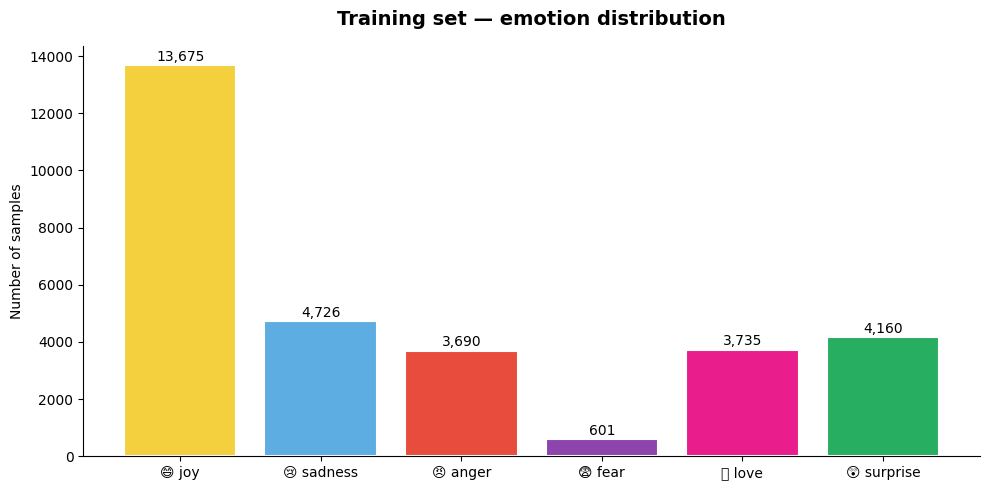

Saved to label_distribution.png


In [ ]:
train_labels = dataset['train']['label']
label_counts = pd.Series(train_labels).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#f4d03f', '#5dade2', '#e74c3c', '#8e44ad', '#e91e8c', '#27ae60']
bars = ax.bar(
    [f"{LABEL_EMOJIS[i]} {LABEL_NAMES[i]}" for i in range(6)],
    label_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
ax.set_title('Training set — emotion distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of samples')
ax.spines[['top', 'right']].set_visible(False)
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to label_distribution.png")

## Cell 7 — Tokenize

In [ ]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=128  # Lyrics can be long — 128 tokens is good balance
    )

print("Tokenizing...")
tokenized = dataset.map(tokenize, batched=True, batch_size=256)
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Tokenized dataset:")
print(tokenized)
print("\nSample input_ids shape:", tokenized['train'][0]['input_ids'].shape)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing...


Map:   0%|          | 0/30587 [00:00<?, ? examples/s]

Map:   0%|          | 0/3834 [00:00<?, ? examples/s]

Map:   0%|          | 0/3821 [00:00<?, ? examples/s]

Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 30587
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3834
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3821
    })
})

Sample input_ids shape: torch.Size([128])


## Cell 8 — Load model

In [ ]:
id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
label2id = {name: i for i, name in enumerate(LABEL_NAMES)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,958,086
Trainable parameters: 66,958,086


## Cell 9 — Metrics

In [ ]:
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='weighted')
    return {
        'accuracy': acc['accuracy'],
        'f1_weighted': f1['f1']
    }

print("Metrics function ready.")

Metrics function ready.


## Cell 10 — Training arguments

In [ ]:
HF_USERNAME = 'Reiiham'  # <-- your HuggingFace username
MODEL_REPO  = f'{HF_USERNAME}/moodpulse-emotion'

training_args = TrainingArguments(
    output_dir='./moodpulse-emotion',
    hub_model_id=MODEL_REPO,

    # Training
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',

    # Evaluation
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,

    # Logging
    logging_steps=50,
    report_to='none',

    # HuggingFace Hub
    push_to_hub=True,
    hub_strategy='end',

    # Colab optimizations
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
)

print(f"Model will be pushed to: https://huggingface.co/{MODEL_REPO}")
print(f"Training on GPU: {torch.cuda.is_available()}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Model will be pushed to: https://huggingface.co/Reiiham/moodpulse-emotion
Training on GPU: True


In [ ]:
from torch import nn
import torch
#To add to see if the loss will be less after + add more epochs
# Count class frequencies
label_counts = pd.Series(tokenized['train']['labels']).value_counts().sort_index()
total = len(tokenized['train'])
class_weights = torch.tensor(
    [total / (6 * label_counts[i]) for i in range(6)],
    dtype=torch.float
).to('cuda' if torch.cuda.is_available() else 'cpu')

print("Class weights:", class_weights)

# Custom trainer with weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

## Cell 11 — Train! ⚡
Expected time on Colab T4: ~25-35 minutes

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting training...")
train_result = trainer.train()

print("\n--- Training complete ---")
print(f"Training loss:    {train_result.training_loss:.4f}")
print(f"Training runtime: {train_result.metrics['train_runtime']:.1f}s")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.677774,0.694784,0.758216,0.760041
2,0.614916,0.662299,0.766302,0.766071
3,0.480352,0.689118,0.764997,0.765484
4,0.391105,0.706940,0.767084,0.767439


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



--- Training complete ---
Training loss:    0.6173
Training runtime: 423.7s


## Cell 12 — Evaluate on test set

In [ ]:
print("Evaluating on test set...")
results = trainer.evaluate(tokenized['test'])

print("\n===== TEST RESULTS =====")
print(f"Accuracy:    {results['eval_accuracy']:.4f} ({results['eval_accuracy']*100:.2f}%)")
print(f"F1 Weighted: {results['eval_f1_weighted']:.4f}")
print(f"Loss:        {results['eval_loss']:.4f}")

Evaluating on test set...



===== TEST RESULTS =====
Accuracy:    0.7584 (75.84%)
F1 Weighted: 0.7566
Loss:        0.7321


## Cell 13 — Confusion matrix

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_8129/3268708930.py:32: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


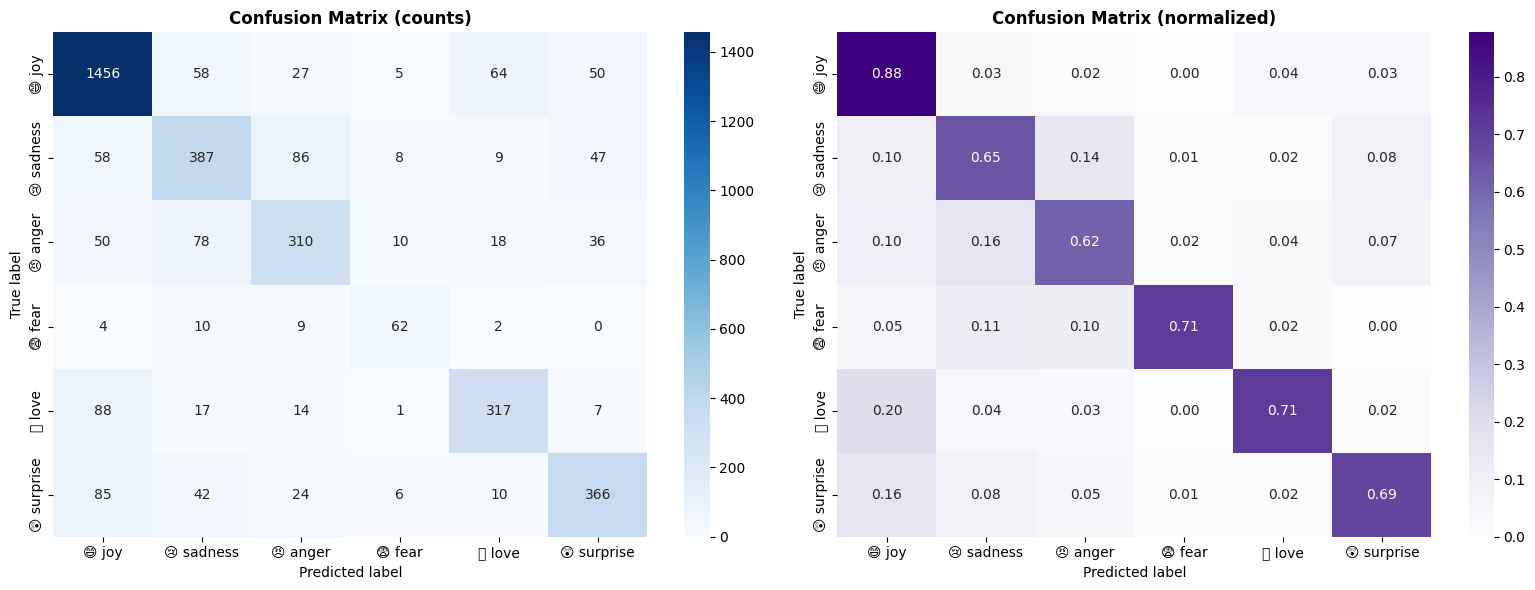


Classification Report:
              precision    recall  f1-score   support

       😄 joy       0.84      0.88      0.86      1660
   😢 sadness       0.65      0.65      0.65       595
     😠 anger       0.66      0.62      0.64       502
      😨 fear       0.67      0.71      0.69        87
      💖 love       0.75      0.71      0.73       444
  😲 surprise       0.72      0.69      0.70       533

    accuracy                           0.76      3821
   macro avg       0.72      0.71      0.71      3821
weighted avg       0.76      0.76      0.76      3821



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

predictions_output = trainer.predict(tokenized['test'])
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

# Confusion matrix
cm = confusion_matrix(true_labels, preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"{LABEL_EMOJIS[i]} {n}" for i, n in enumerate(LABEL_NAMES)],
            yticklabels=[f"{LABEL_EMOJIS[i]} {n}" for i, n in enumerate(LABEL_NAMES)],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=[f"{LABEL_EMOJIS[i]} {n}" for i, n in enumerate(LABEL_NAMES)],
            yticklabels=[f"{LABEL_EMOJIS[i]} {n}" for i, n in enumerate(LABEL_NAMES)],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized)', fontweight='bold')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, preds,
      target_names=[f"{LABEL_EMOJIS[i]} {n}" for i, n in enumerate(LABEL_NAMES)]))

## Cell 14 — Push model + tokenizer + model card to HuggingFace Hub

In [ ]:
# Save locally first
trainer.save_model('./moodpulse-emotion-final')
tokenizer.save_pretrained('./moodpulse-emotion-final')

# Push to Hub
print(f"Pushing to https://huggingface.co/{MODEL_REPO} ...")
trainer.push_to_hub()
tokenizer.push_to_hub(MODEL_REPO)

print(f"\nModel live at: https://huggingface.co/{MODEL_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...emotion/model.safetensors:   0%|          |  575kB /  268MB            

...

  ...emotion/model.safetensors:   3%|2         | 7.99MB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.


README.md: 0.00B [00:00, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.



Model live at: https://huggingface.co/Reiiham/moodpulse-emotion


## Cell 15 — Write model card

In [ ]:
from huggingface_hub import HfApi

model_card = f"""---
language: en
license: apache-2.0
tags:
  - text-classification
  - emotion-detection
  - music-mood
  - distilbert
  - fine-tuned
datasets:
  - go_emotions
metrics:
  - accuracy
  - f1
model-index:
  - name: moodpulse-emotion
    results:
      - task:
          type: text-classification
        dataset:
          name: go_emotions
          type: go_emotions
        metrics:
          - type: accuracy
            value: {results['eval_accuracy']:.4f}
          - type: f1
            value: {results['eval_f1_weighted']:.4f}
---

# 🎵 MoodPulse Emotion Classifier

Fine-tuned `distilbert-base-uncased` on [GoEmotions](https://huggingface.co/datasets/go_emotions)
for music mood prediction. Part of the **MoodPulse** project — an app that analyzes your
Spotify top tracks and predicts your current emotional state.

## Labels

| ID | Label | Emoji |
|----|-------|-------|
| 0  | joy      | 😄 |
| 1  | sadness  | 😢 |
| 2  | anger    | 😠 |
| 3  | fear     | 😨 |
| 4  | love     | 💖 |
| 5  | surprise | 😲 |

## Performance

| Metric | Score |
|--------|-------|
| Accuracy | {results['eval_accuracy']*100:.2f}% |
| F1 (weighted) | {results['eval_f1_weighted']:.4f} |

## Usage

```python
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="{MODEL_REPO}",
    return_all_scores=True
)

result = classifier("I feel so alive, dancing under the stars!")
# Returns scores for all 6 emotions
```

## Training details

- **Base model:** distilbert-base-uncased
- **Dataset:** GoEmotions (simplified, 27 labels collapsed to 6)
- **Epochs:** 4 (early stopping)
- **Batch size:** 32
- **Learning rate:** 2e-5 with cosine scheduler
- **Hardware:** Google Colab T4 GPU

## About MoodPulse

MoodPulse connects to your Spotify account, fetches your top 5 tracks of the week,
analyzes the lyrics using this model + Spotify audio features (valence, energy, danceability),
and predicts your current emotional mood with a clean data visualization.

Built by [Reiiham](https://github.com/Reiiham)
"""

api = HfApi()
api.upload_file(
    path_or_fileobj=model_card.encode(),
    path_in_repo='README.md',
    repo_id=MODEL_REPO,
    repo_type='model'
)

print("Model card uploaded!")
print(f"Visit: https://huggingface.co/{MODEL_REPO}")

Model card uploaded!
Visit: https://huggingface.co/Reiiham/moodpulse-emotion


## Cell 16 — Quick inference test 🎤

In [ ]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model='./moodpulse-emotion-final',
    return_all_scores=True,
    device=0 if torch.cuda.is_available() else -1
)

test_lyrics = [
    "I can't stop smiling, everything feels perfect today",
    "She's gone and I'm left here crying in the rain",
    "I want to break everything, this rage won't stop",
    "My heart is pounding, I don't know what's coming next",
    "Every time I see you my heart skips a beat",
    "I never expected this, it came out of nowhere"
]

print("\n===== INFERENCE TEST =====\n")
for text in test_lyrics:
    result = classifier(text)

    # Handle both output formats (list of list or list of dict)
    if isinstance(result[0], list):
        scores = result[0]   # [[{label, score}, ...]]
    else:
        scores = result      # [{label, score}, ...]

    top = max(scores, key=lambda x: x['score'])
    label_idx = LABEL_NAMES.index(top['label'])
    print(f"{LABEL_EMOJIS[label_idx]} [{top['label'].upper():8s}] {top['score']*100:5.1f}% | {text[:55]}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


===== INFERENCE TEST =====

😄 [JOY     ]  99.1% | I can't stop smiling, everything feels perfect today
😢 [SADNESS ]  96.2% | She's gone and I'm left here crying in the rain
😠 [ANGER   ]  76.1% | I want to break everything, this rage won't stop
😲 [SURPRISE]  86.9% | My heart is pounding, I don't know what's coming next
😲 [SURPRISE]  62.0% | Every time I see you my heart skips a beat
😢 [SADNESS ]  85.6% | I never expected this, it came out of nowhere


In [ ]:
!pip install -q lyricsgenius

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.7 MB/s eta 0:00:00


## Cell 17 — Visualize inference scores (radar chart preview)

Analyzing your songs...

  😨 The Night We Met — FEAR (39.0%)
  💖 I Bet on Losing Dogs — LOVE (70.9%)
  😄 Jump — JOY (86.9%)
  😲 Nobody — SURPRISE (47.2%)
  😢 No surprises — SADNESS (58.5%)


/tmp/ipykernel_8129/2693493130.py:108: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8129/2693493130.py:109: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  plt.savefig('per_song_emotions.png', dpi=150, bbox_inches='tight')


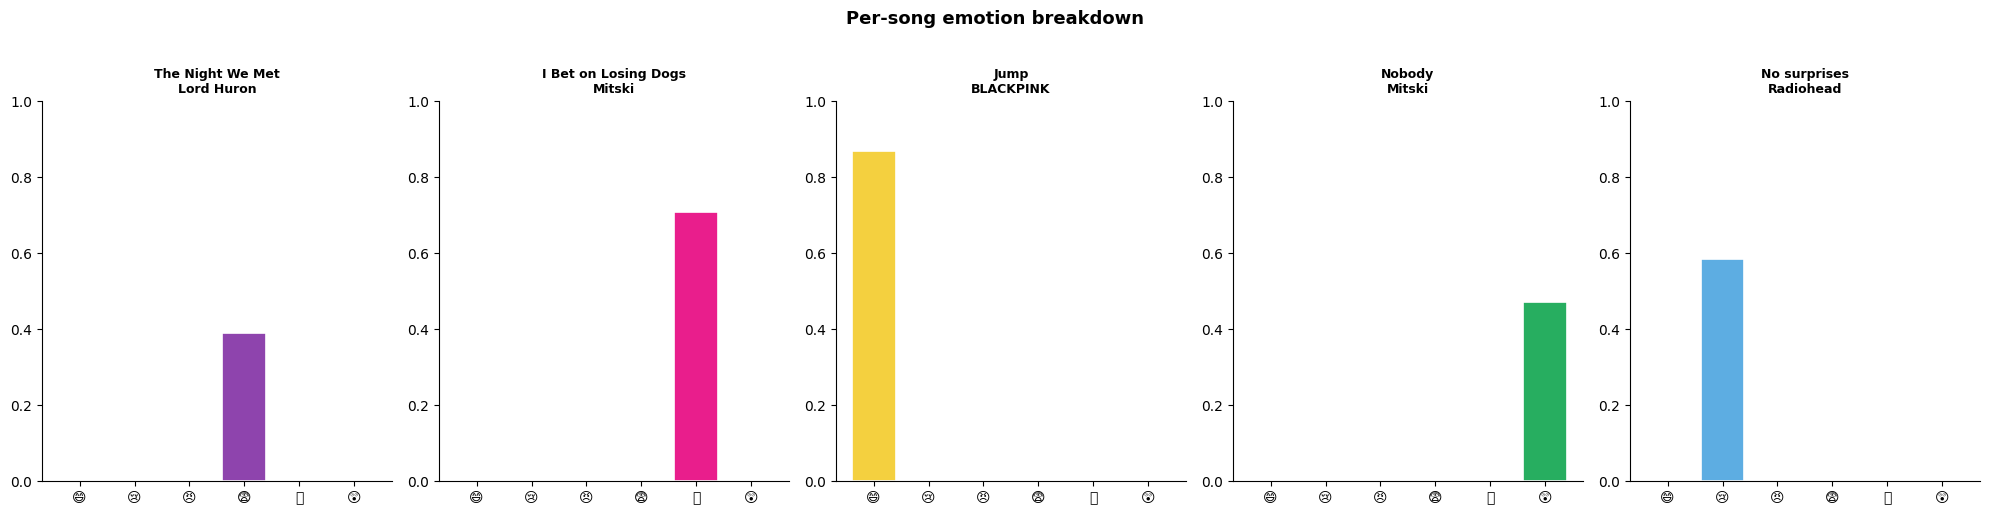

/tmp/ipykernel_8129/2693493130.py:132: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8129/2693493130.py:133: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  plt.savefig('mood_radar_real.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128150 (\N{SPARKLING HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


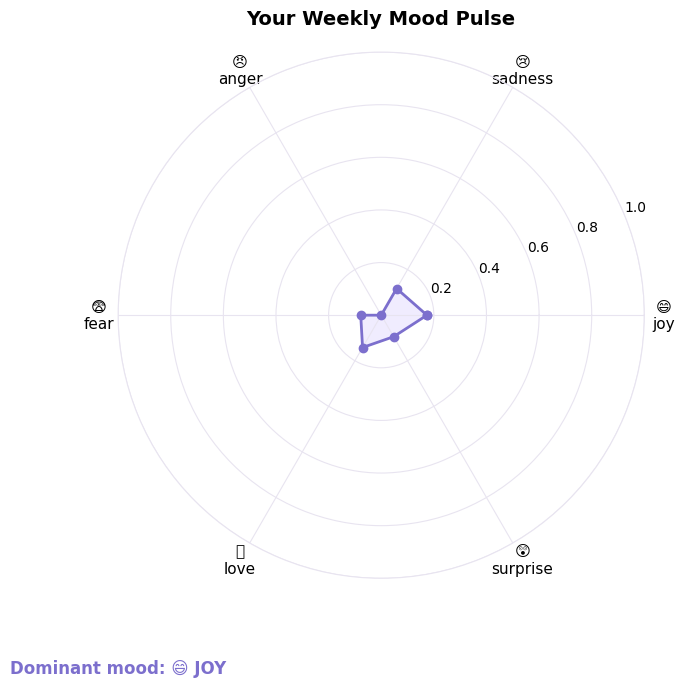


  Dominant mood: 😄 JOY
  😄 joy      ███ 17.4%
  😢 sadness  ██ 11.7%
  😠 anger     0.0%
  😨 fear     █ 7.8%
  💖 love     ██ 14.2%
  😲 surprise █ 9.4%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

MY_SONGS = [
    {
        "title": "The Night We Met",
        "artist": "Lord Huron",
        "lyrics": """
        I had all and then most of you, some and now none of you
        Take me back to the night we met
        I don't know what I'm supposed to do, haunted by the ghost of you
        Oh, take me back to the night we met
        When the night was full of terrors and your eyes were filled with tears
        When you had not touched me yet, take me back to the night we met
        """
    },
    {
        "title": "I Bet on Losing Dogs",
        "artist": "Mitski",
        "lyrics": """
        I bet on losing dogs, I know they're losing and I'll pay
        For the pleasure of their company
        I bet on losing dogs, I always want them to stay
        I know they're losing and I'll pay
        I bet on losing dogs, I know they're losing
        Hold them close, feel their heartbeats
        """
    },
    {
        "title": "Jump",
        "artist": "BLACKPINK",
        "lyrics": """
        Jump jump jump jump, let's go
        When I wake up in the morning feeling brand new
        Got that energy, yeah I'm coming for you
        Jump up, never stop, we're going higher
        Light it up, set the world on fire
        We're unstoppable, unbreakable tonight
        """
    },
    {
        "title": "Nobody",
        "artist": "Mitski",
        "lyrics": """
        I've been driving on this highway alone
        Nobody knows me at all
        I've been waiting for the sky to fall
        I've got nobody nobody nobody
        And after the party I'll find you there
        """
    },
    { "title": "No surprises",
        "artist": "Radiohead",
        "lyrics": """
        He was sick of his clock stopping
        It winds him up, that girl still
        Snoring next to him
        He was sick of his excuses
        To not take off her dress when
        Bleeding in the bathroom
        The watch smashed, and he got restless
        He sighs in broken English
        """}
]  # <-- this was missing!

# Per-song analysis
print("Analyzing your songs...\n")
all_scores = np.zeros(6)
song_results = []

for song in MY_SONGS:  # <-- was sample_songs
    result = classifier(song["lyrics"])  # <-- use the lyrics key
    scores = result[0] if isinstance(result[0], list) else result

    song_scores = {s['label']: s['score'] for s in scores}
    top = max(scores, key=lambda x: x['score'])
    top_idx = LABEL_NAMES.index(top['label'])

    song_results.append({
        "title": song["title"],
        "artist": song["artist"],
        "top_label": top['label'],
        "top_emoji": LABEL_EMOJIS[top_idx],
        "top_score": top['score'],
        "scores": song_scores
    })

    for s in scores:
        all_scores[LABEL_NAMES.index(s['label'])] += s['score']

    print(f"  {LABEL_EMOJIS[top_idx]} {song['title']} — {top['label'].upper()} ({top['score']*100:.1f}%)")

all_scores /= len(MY_SONGS)

# Per-song bar chart
bar_colors = ['#f4d03f','#5dade2','#e74c3c','#8e44ad','#e91e8c','#27ae60']
fig, axes = plt.subplots(1, len(song_results), figsize=(4 * len(song_results), 5))

for ax, sr in zip(axes, song_results):
    vals = [sr['scores'].get(label, 0) for label in LABEL_NAMES]
    ax.bar([f"{LABEL_EMOJIS[i]}" for i in range(6)], vals,
           color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.set_ylim(0, 1)
    ax.set_title(f"{sr['title']}\n{sr['artist']}", fontsize=9, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Per-song emotion breakdown', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('per_song_emotions.png', dpi=150, bbox_inches='tight')
plt.show()

# Overall radar chart
angles = np.linspace(0, 2 * np.pi, 6, endpoint=False).tolist()
values = all_scores.tolist()
angles += angles[:1]
values += values[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, values, 'o-', linewidth=2, color='#7c6fcd')
ax.fill(angles, values, alpha=0.25, color='#c4b5fd')
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f"{LABEL_EMOJIS[i]}\n{LABEL_NAMES[i]}" for i in range(6)], fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Your Weekly Mood Pulse', size=14, fontweight='bold', pad=20)
ax.grid(color='#e8e4f0', linewidth=0.8)
ax.spines['polar'].set_color('#e8e4f0')

dominant_idx = np.argmax(all_scores)
ax.text(0, -0.18, f"Dominant mood: {LABEL_EMOJIS[dominant_idx]} {LABEL_NAMES[dominant_idx].upper()}",
        transform=ax.transAxes, ha='center', fontsize=12, color='#7c6fcd', fontweight='bold')

plt.tight_layout()
plt.savefig('mood_radar_real.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*40}")
print(f"  Dominant mood: {LABEL_EMOJIS[dominant_idx]} {LABEL_NAMES[dominant_idx].upper()}")
print(f"{'='*40}")
for i, name in enumerate(LABEL_NAMES):
    bar = '█' * int(all_scores[i] * 20)
    print(f"  {LABEL_EMOJIS[i]} {name:8s} {bar} {all_scores[i]*100:.1f}%")